In [81]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import itertools as it
import ast  # ast (Abstract Syntax Trees) is used for safely evaluating string literals
import os   # Used for creating and cleaning up the dummy file

from matplotlib.ticker import LogLocator, MaxNLocator, AutoLocator

In [520]:
### Import .csv file containing variance/expectation/time vs depth(column) vs graph(row) data
df = pd.read_csv(r'data_output.csv')

In [522]:
df

,1,2,3,4,5,6,7,8,9,10,...,31,32,33,34,35,36,37,38,39,40
0,"{'variance': 0.0006739144081845844, 'expectati...","{'variance': 0.0018228715358671905, 'expectati...","{'variance': 0.0018381809283893123, 'expectati...","{'variance': 0.0018392577944554157, 'expectati...","{'variance': 0.0018424875865180872, 'expectati...","{'variance': 0.0027801979828669583, 'expectati...","{'variance': 0.0032173151119701516, 'expectati...","{'variance': 0.003142525318910645, 'expectatio...","{'variance': 0.0034733371887375845, 'expectati...","{'variance': 0.003543187254408933, 'expectatio...",...,"{'variance': 0.005019654423394846, 'expectatio...","{'variance': 0.005017107191058094, 'expectatio...","{'variance': 0.005114789946858819, 'expectatio...","{'variance': 0.005235010068482606, 'expectatio...","{'variance': 0.0054503859040646715, 'expectati...","{'variance': 0.005620544944795627, 'expectatio...","{'variance': 0.0047878310436866335, 'expectati...","{'variance': 0.0050585794470363755, 'expectati...","{'variance': 0.00483506812476802, 'expectation...","{'variance': 0.004896396334468995, 'expectatio..."
1,"{'variance': 0.0017516678408977296, 'expectati...","{'variance': 0.0036048268830304563, 'expectati...","{'variance': 0.003059084985571195, 'expectatio...","{'variance': 0.00393703724712065, 'expectation...","{'variance': 0.004293681726774476, 'expectatio...","{'variance': 0.003411054481250322, 'expectatio...","{'variance': 0.00415317373266121, 'expectation...","{'variance': 0.004526360306341195, 'expectatio...","{'variance': 0.004201201853642374, 'expectatio...","{'variance': 0.0042178936066438, 'expectation'...",...,"{'variance': 0.005172368081547418, 'expectatio...","{'variance': 0.004914204662308895, 'expectatio...","{'variance': 0.00518742731541306, 'expectation...","{'variance': 0.005443368529114517, 'expectatio...","{'variance': 0.004833948574680525, 'expectatio...","{'variance': 0.005083337194109544, 'expectatio...","{'variance': 0.006073062919019942, 'expectatio...","{'variance': 0.005133105647679445, 'expectatio...","{'variance': 0.004766011466592632, 'expectatio...","{'variance': 0.004881984030809051, 'expectatio..."
2,"{'variance': 0.0009759740127703512, 'expectati...","{'variance': 0.002711701858466081, 'expectatio...","{'variance': 0.0028332946334080488, 'expectati...","{'variance': 0.002695223129048645, 'expectatio...","{'variance': 0.0024731916207231604, 'expectati...","{'variance': 0.003313153934747219, 'expectatio...","{'variance': 0.0029832256674336742, 'expectati...","{'variance': 0.0034568262561715853, 'expectati...","{'variance': 0.0033333144448904283, 'expectati...","{'variance': 0.0029391718820452584, 'expectati...",...,"{'variance': 0.004430099846789412, 'expectatio...","{'variance': 0.004376633982098245, 'expectatio...","{'variance': 0.003788234535160306, 'expectatio...","{'variance': 0.003921602650330731, 'expectatio...","{'variance': 0.00412271432186791, 'expectation...","{'variance': 0.003971433044804677, 'expectatio...","{'variance': 0.004363019573121665, 'expectatio...","{'variance': 0.003971999038134509, 'expectatio...","{'variance': 0.004263576495112503, 'expectatio...","{'variance': 0.0038685758108242263, 'expectati..."
3,"{'variance': 0.0006141473380426731, 'expectati...","{'variance': 0.0019510484867434241, 'expectati...","{'variance': 0.00163636283154348, 'expectation...","{'variance': 0.0014879674841437823, 'expectati...","{'variance': 0.0014012984225348765, 'expectati...","{'variance': 0.0020310591460829695, 'expectati...","{'variance': 0.0023315093393965107, 'expectati...","{'variance': 0.0023328764053248234, 'expectati...","{'variance': 0.0020446286575336132, 'expectati...","{'variance': 0.0020631151574261003, 'expectati...",...,"{'variance': 0.003587197459025528, 'expectatio...","{'variance': 0.0035603301435527205, 'expectati...","{'variance': 0.004130081553885021, 'expectatio...","{'variance': 0.004070491390493415, 'expectatio...","{'variance': 0.0037116318498093288, 'expectati...","{'variance': 0.0038

In [524]:
# Apply literal_eval to each column
for col in df.columns:
    df[col] = df[col].apply(literal_eval)

In [336]:
### Plotting ###

# Helper function to save plots
def ensure_dir(directory):
    """Creates a directory if it doesn't exist."""
    if not os.path.exists(directory):
        os.makedirs(directory)
        print(f"Created directory: {directory}")

def save_plot(fig, outdir, filename, show=True):
    """Saves the plot to a file."""
    filepath = os.path.join(outdir, filename)
    fig.savefig(filepath, bbox_inches='tight', dpi=300)
    fig.savefig(filepath.replace('.png', '.pdf'), bbox_inches='tight')
    print(f"Plot saved to {filepath} (and .pdf)")
    if show:
        plt.show()
    else:
        plt.close(fig)

In [338]:
G1 = df.iloc[0]
print(G1.iloc[1])
# returns {'variance': 0.0018228715358671905, 'expectation': 0.534087626698114, 'time': 2.435081720352173}

{'variance': 0.0018228715358671905, 'expectation': 0.534087626698114, 'time': 2.435081720352173}


In [340]:
G1 = df.iloc[0]
print(G1.iloc[1]['expectation'])
# returns 0.534087626698114

0.534087626698114


In [526]:
def plot_expectation_data(df, n_wires: int, n_param_samples: int =None,
                          outdir: str = "./figures", show: bool = True):
    """
    For fixed n vertices:
    Plot expectation value vs depth curves, per graph instance.
    Reads data directly from a prepared DataFrame.
    Saves as PNG and PDF.
    """
    print("\nStarting plotting function...")
    ensure_dir(outdir)
    fig, ax = plt.subplots(figsize=(3.5, 3.0))

    # Define marker styles (5 random graphs)
    marker_styles = it.cycle(['h','+','x','o','s',])

    # Get all unique graph IDs from the DataFrame
    G_1 = df.iloc[0]
    G_2 = df.iloc[1]
    G_3 = df.iloc[2]
    G_4 = df.iloc[3]
    G_5 = df.iloc[4]
    
    graphs = [G_1, G_2, G_3, G_4, G_5] # Sort them to keep order consistent
    graph_labels = it.cycle(['G1', 'G2', 'G3', 'G4', 'G5'])
    # Group the DataFrame by 'G_i' and plot each group
    for g in graphs:
        
        # Get the depths and expectations
        depths =[p+1 for p in range(df.shape[1])]
        expectations = [g.iloc[p-1]['expectation'] for p in depths]
        current_marker = next(marker_styles)
        current_label = next(graph_labels)
        ax.plot(depths, expectations, marker=current_marker, label=current_label)
    # --- All your formatting code remains the same ---
    ax.set_xlabel(r'Depth $p$')
    ax.set_xlim(left=0)
    ax.yaxis.set_major_locator(AutoLocator())
    ax.xaxis.set_major_locator(MaxNLocator(integer=True))
    ax.set_ylabel("Expectation of the loss function")
    # ax.set_yscale("log")
    # ax.set_title("Expectation vs Depth")
    ax.legend(fontsize=8)
    ax.grid(True, which='both')

    # Use the helper function to save the plot
    plot_filename = f"expectation_vs_depth_n_{n_wires}_{n_param_samples}_params.png"
    save_plot(fig, outdir, plot_filename, show=show)

In [528]:
def plot_variance_data(df, n_wires: int, n_param_samples: int =None,
                          outdir: str = "./figures", show: bool = True):
    """
    For fixed n vertices:
    Plot variance vs depth curves, per graph instance.
    Reads data directly from a prepared DataFrame.
    Saves as PNG and PDF.
    """
    print("\nStarting plotting function...")
    ensure_dir(outdir)
    fig, ax = plt.subplots(figsize=(3.5, 3.0))

    # Define marker styles (5 random graphs)
    marker_styles = it.cycle(['h','+','x','o','s',])

    # Get all unique graph IDs from the DataFrame
    G_1 = df.iloc[0]
    G_2 = df.iloc[1]
    G_3 = df.iloc[2]
    G_4 = df.iloc[3]
    G_5 = df.iloc[4]
    
    graphs = [G_1, G_2, G_3, G_4, G_5] # Sort them to keep order consistent
    graph_labels = it.cycle(['G1', 'G2', 'G3', 'G4', 'G5'])
    # Group the DataFrame by 'G_i' and plot each group
    for g in graphs:
        
        # Get the depths and expectations
        depths =[p+1 for p in range(df.shape[1])]
        expectations = [g.iloc[p-1]['variance'] for p in depths]
        current_marker = next(marker_styles)
        current_label = next(graph_labels)
        ax.plot(depths, expectations, marker=current_marker, label=current_label)
    # --- All formatting code goes the same ---
    ax.set_xlabel(r"Depth $p$")
    ax.set_xlim(left=0)
    ax.xaxis.set_major_locator(MaxNLocator(integer=True))
    
    ax.set_ylabel("Variance of the loss function")
    ax.set_yscale("log")
    ax.set_ylim([4e-4, 1e-2])
    custom_ticks = [5e-4, 1e-3,5e-3, 1e-2]
    custom_labels = [
        r"$5 \times 10^{-4}$",
        r"$10^{-3}$",
        r"$5 \times 10^{-3}$",
        r"$10^{-2}$"]
    ax.set_yticks(custom_ticks, labels=custom_labels)
    #ax.set_title("Variance vs Depth")
    ax.legend(fontsize=8)
    ax.grid(True, which='both')

    # Use the helper function to save the plot
    plot_filename = f"variance_vs_depth_n_{n_wires}_{n_param_samples}_params.png"
    save_plot(fig, outdir, plot_filename, show=show)


Starting plotting function...
Plot saved to ./figures/expectation_vs_depth_n_8_100_params.png (and .pdf)


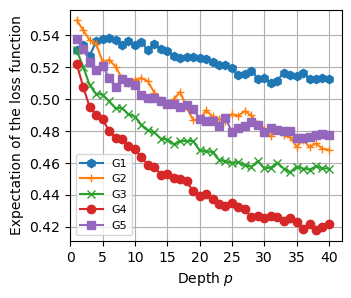


Starting plotting function...
Plot saved to ./figures/variance_vs_depth_n_8_100_params.png (and .pdf)


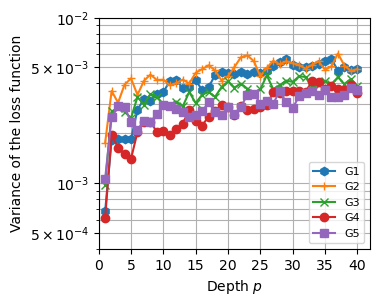

In [530]:
# Expectation and Variance plots

n_wires = 8
n_graphs = 5
max_depth = 40
n_param_samples=100
rng = np.random.default_rng(1234)

plot_expectation_data(df, n_wires, n_param_samples)
plot_variance_data(df, n_wires, n_param_samples)

In [532]:
### Import .csv file containing variance vs n_qubits(columns) vs graph(row) data
df2 = pd.read_csv(r'varrange_output.csv')

In [534]:
df2

,3,4,5,6,7,8,9,10
0,0.006311951214166953,0.004027582234347504,0.0021033475204796175,0.0015443518484489624,0.0012376982916969229,0.000619267232217736,0.0006657155082828511,0.00030030871542216405
1,"[0.006311951214166953, 0.031197205411697727, 0...","[0.004027582234347504, 0.010996154007339977, 0...","[0.0025713619147714408, 0.0022468809463395472,...","[0.0015443518484489624, 0.002373543646671945, ...","[0.0013795828202087385, 0.0023200941327885943,...","[0.001051599362717054, 0.000619267232217736, 0...","[0.0006657155082828511, 0.0009052810277389364,...","[0.0007278303889777933, 0.00036740867174853945..."
2,0.05520126417152937,0.04797086144129891,0.021396351200560007,0.017306190291448174,0.00829030492363237,0.005005086572544493,0.004286400609539693,0.0026434918494474234
3,"[0.05471478312891632, 0.044575485616325114, 0....","[0.04797086144129891, 0.021739108388947055, 0....","[0.02032655471638972, 0.016550242392786445, 0....","[0.008486401147081988, 0.012752157986909035, 0...","[0.007077566999839917, 0.00829030492363237, 0....","[0.004685846205067398, 0.0037758865819807422, ...","[0.0026016073288527538, 0.004097746334778944, ...","[0.0026434918494474234, 0.0012837228806716451,..."


In [536]:
# print the variance data for n=3 up to n=10

print(df2['3'][0]) #absolute minimum
print(df2['3'][1]) #minimum variance over all depths for each 5 graphs
print(df2['3'][2]) #absolute maximum
print(df2['3'][3]) #maximum variance over all depths for each 5 graphs

0.006311951214166953
[0.006311951214166953, 0.031197205411697727, 0.030085981753464143, 0.009784452207258923, 0.008015561504340287]
0.05520126417152937
[0.05471478312891632, 0.044575485616325114, 0.04563316221865042, 0.05520126417152937, 0.054874517117819065]


In [542]:
# Plots results from varrange_output.csv
def plot_variance_range(df, max_depth: int = None, n_param_samples: int = None,
                        outdir: str = "./figures", ref_scale: float = 1.0, show: bool = True):
    """
    For use with Plot min/max empirical variances across n, with an overlay reference curve ~ n^-4.
    Saves as PNG and PDF.
    """
    ensure_dir(outdir)
    
    mins = []
    maxs = []
    for n in range(df.shape[1]):
        column_index = df.columns[n]
        mins.append(float(df[column_index][0]))
        maxs.append(float(df[column_index][2]))

    ns_ax =[n+3 for n in range(df.shape[1])] #starting at n=3
    fig, ax = plt.subplots(figsize=(3.5, 3.0))
    ax.fill_between(ns_ax, mins, maxs, color="skyblue", alpha=0.4, label="Variance range")
    ax.plot(ns_ax, mins, "c--", label="Minimum")
    ax.plot(ns_ax, maxs, "c-", label="Maximum")

    # Overlay reference curve c * n^-4
    ref_curve = [ref_scale * (n ** -4) for n in ns_ax]
    ax.plot(ns_ax, ref_curve,'m-.', linewidth=2, label="Analytical lower bound")
    
    # --- All formatting code goes the same ---
    ax.set_xlabel(r"$n$ qubits")
    ax.set_ylabel("Variance of the loss function")
    ax.set_yscale("log")
    ax.yaxis.set_major_locator(LogLocator(base=10.0))
   # ax.set_title(f"Variance range across graph instances")
    ax.grid(True, which="both")
    ax.legend(fontsize=8)

    save_plot(fig, outdir, f"variance_range_p_{max_depth}_{n_param_samples}_params.png", show=show)

Plot saved to ./figures/variance_range_p_40_100_params.png (and .pdf)


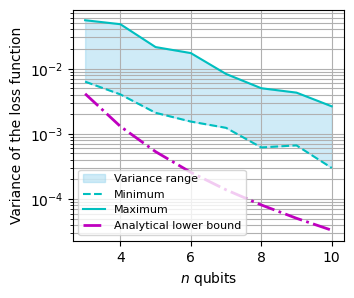

In [544]:
# Variance range plots

max_depth = 40
n_param_samples=100
rng = np.random.default_rng(1234)

plot_variance_range(df2, max_depth, n_param_samples, ref_scale = 1/3)